In [20]:
import torch
from torch import nn
from matplotlib import pyplot as plt
import os
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
from PIL import Image
from matplotlib import pyplot as plt
import pandas as pd
import os
import requests
import zipfile

# Exercise 1

We can improve the single-shot multibox detection by improving the loss function. Replace the $\ell_1$ norm loss with the _smooth $\ell_1$ norm loss_ for the predicted offsets. This loss function uses a square function around zero for smoothness, which is controlled by the hyperparameter $\sigma$:

$$
    f(x) =
        \begin{cases}
        (\sigma x)^2/2,& \textrm{if }|x| < 1/\sigma^2\\
        |x|-0.5/\sigma^2,& \textrm{otherwise}
        \end{cases}
$$

When $\sigma$ is very large, this loss is similar to the $\ell_1$ norm loss. When its value is smaller, the loss function is smoother.


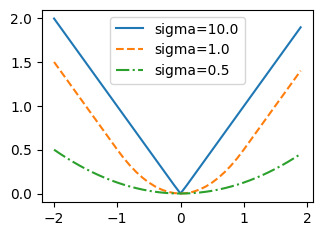

In [21]:
def set_figsize(figsize=(3.5, 2.5)):
    """Set the figure size for matplotlib."""
    plt.rcParams["figure.figsize"] = figsize


def smooth_l1(data, scalar):
    out = []
    for i in data:
        if abs(i) < 1 / (scalar**2):
            out.append(((scalar * i) ** 2) / 2)
        else:
            out.append(abs(i) - 0.5 / (scalar**2))
    return torch.tensor(out)


def smooth_l1_loss(pred, target, scalar=1.0):
    delta = pred - target
    mask = abs(delta) < 1 / (scalar**2)
    out = torch.ones_like(delta)
    out[mask] = (scalar * delta[mask]) ** 2 / 2
    out[~mask] = abs(delta[~mask]) - 0.5 / (scalar**2)
    return out


sigmas = [10, 1, 0.5]
lines = ["-", "--", "-."]
x = torch.arange(-2, 2, 0.1)
set_figsize()

for l, s in zip(lines, sigmas):
    y = smooth_l1(x, scalar=s)
    plt.plot(x, y, l, label="sigma=%.1f" % s)
plt.legend()

In [22]:
def cls_predictor(num_inputs, num_anchors, num_classes):
    return nn.Conv2d(
        num_inputs, num_anchors * (num_classes + 1), kernel_size=3, padding=1
    )


def bbox_predictor(num_inputs, num_anchors):
    return nn.Conv2d(num_inputs, num_anchors * 4, kernel_size=3, padding=1)


def forward(x, block):
    return block(x)


Y1 = forward(torch.zeros((2, 8, 20, 20)), cls_predictor(8, 5, 10))
Y2 = forward(torch.zeros((2, 16, 10, 10)), cls_predictor(16, 3, 10))
Y1.shape, Y2.shape


def flatten_pred(pred):
    return torch.flatten(pred.permute(0, 2, 3, 1), start_dim=1)


def concat_preds(preds):
    return torch.cat([flatten_pred(p) for p in preds], dim=1)


def down_sample_blk(in_channels, out_channels):
    blk = []
    for _ in range(2):
        blk.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))
        blk.append(nn.BatchNorm2d(out_channels))
        blk.append(nn.ReLU())
        in_channels = out_channels
    blk.append(nn.MaxPool2d(2))
    return nn.Sequential(*blk)


def base_net():
    blk = []
    num_filters = [3, 16, 32, 64]
    for i in range(len(num_filters) - 1):
        blk.append(down_sample_blk(num_filters[i], num_filters[i + 1]))
    return nn.Sequential(*blk)


def get_blk(i):
    if i == 0:
        blk = base_net()
    elif i == 1:
        blk = down_sample_blk(64, 128)
    elif i == 4:
        blk = nn.AdaptiveMaxPool2d((1, 1))
    else:
        blk = down_sample_blk(128, 128)
    return blk


def multibox_prior(data, sizes, ratios):
    """Generate anchor boxes with different shapes centered on each pixel."""
    in_height, in_width = data.shape[-2:]
    device, num_sizes, num_ratios = data.device, len(sizes), len(ratios)
    boxes_per_pixel = num_sizes + num_ratios - 1
    size_tensor = torch.tensor(sizes, device=device)
    ratio_tensor = torch.tensor(ratios, device=device)
    # Offsets are required to move the anchor to the center of a pixel. Since
    # a pixel has height=1 and width=1, we choose to offset our centers by 0.5
    offset_h, offset_w = 0.5, 0.5
    steps_h = 1.0 / in_height  # Scaled steps in y axis
    steps_w = 1.0 / in_width  # Scaled steps in x axis

    # Generate all center points for the anchor boxes
    center_h = (torch.arange(in_height, device=device) + offset_h) * steps_h
    center_w = (torch.arange(in_width, device=device) + offset_w) * steps_w
    shift_y, shift_x = torch.meshgrid(center_h, center_w, indexing="ij")
    shift_y, shift_x = shift_y.reshape(-1), shift_x.reshape(-1)

    # Generate `boxes_per_pixel` number of heights and widths that are later
    # used to create anchor box corner coordinates (xmin, xmax, ymin, ymax)
    w = (
        torch.cat(
            (
                size_tensor * torch.sqrt(ratio_tensor[0]),
                sizes[0] * torch.sqrt(ratio_tensor[1:]),
            )
        )
        * in_height
        / in_width
    )  # Handle rectangular inputs
    h = torch.cat(
        (
            size_tensor / torch.sqrt(ratio_tensor[0]),
            sizes[0] / torch.sqrt(ratio_tensor[1:]),
        )
    )
    # Divide by 2 to get half height and half width
    anchor_manipulations = (
        torch.stack((-w, -h, w, h)).T.repeat(in_height * in_width, 1) / 2
    )

    # Each center point will have `boxes_per_pixel` number of anchor boxes, so
    # generate a grid of all anchor box centers with `boxes_per_pixel` repeats
    out_grid = torch.stack(
        [shift_x, shift_y, shift_x, shift_y], dim=1
    ).repeat_interleave(boxes_per_pixel, dim=0)
    output = out_grid + anchor_manipulations
    return output.unsqueeze(0)


def blk_forward(X, blk, size, ratio, cls_predictor, bbox_predictor):
    Y = blk(X)
    anchors = multibox_prior(Y, sizes=size, ratios=ratio)
    cls_preds = cls_predictor(Y)
    bbox_preds = bbox_predictor(Y)
    return (Y, anchors, cls_preds, bbox_preds)


sizes = [[0.2, 0.272], [0.37, 0.447], [0.54, 0.619], [0.71, 0.79], [0.88, 0.961]]
ratios = [[1, 2, 0.5]] * 5
num_anchors = len(sizes[0]) + len(ratios[0]) - 1

In [23]:
def box_iou(boxes1, boxes2):
    """Compute pairwise IoU across two lists of anchor or bounding boxes."""
    box_area = lambda boxes: ((boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1]))
    # Shape of `boxes1`, `boxes2`, `areas1`, `areas2`: (no. of boxes1, 4),
    # (no. of boxes2, 4), (no. of boxes1,), (no. of boxes2,)
    areas1 = box_area(boxes1)
    areas2 = box_area(boxes2)
    # Shape of `inter_upperlefts`, `inter_lowerrights`, `inters`: (no. of
    # boxes1, no. of boxes2, 2)
    inter_upperlefts = torch.max(boxes1[:, None, :2], boxes2[:, :2])
    inter_lowerrights = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])
    inters = (inter_lowerrights - inter_upperlefts).clamp(min=0)
    # Shape of `inter_areas` and `union_areas`: (no. of boxes1, no. of boxes2)
    inter_areas = inters[:, :, 0] * inters[:, :, 1]
    union_areas = areas1[:, None] + areas2 - inter_areas
    return inter_areas / union_areas


def box_corner_to_center(boxes):
    """Convert from (upper-left, lower-right) to (center, width, height)."""
    x1, y1, x2, y2 = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2
    w = x2 - x1
    h = y2 - y1
    boxes = torch.stack((cx, cy, w, h), axis=-1)
    return boxes


def box_center_to_corner(boxes):
    """Convert from (center, width, height) to (upper-left, lower-right)."""
    cx, cy, w, h = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    x1 = cx - 0.5 * w
    y1 = cy - 0.5 * h
    x2 = cx + 0.5 * w
    y2 = cy + 0.5 * h
    boxes = torch.stack((x1, y1, x2, y2), axis=-1)
    return boxes


def offset_inverse(anchors, offset_preds):
    """Predict bounding boxes based on anchor boxes with predicted offsets."""
    anc = box_corner_to_center(anchors)
    pred_bbox_xy = (offset_preds[:, :2] * anc[:, 2:] / 10) + anc[:, :2]
    pred_bbox_wh = torch.exp(offset_preds[:, 2:] / 5) * anc[:, 2:]
    pred_bbox = torch.cat((pred_bbox_xy, pred_bbox_wh), axis=1)
    predicted_bbox = box_center_to_corner(pred_bbox)
    return predicted_bbox


def nms(boxes, scores, iou_threshold):
    """Sort confidence scores of predicted bounding boxes."""
    B = torch.argsort(scores, dim=-1, descending=True)
    keep = []  # Indices of predicted bounding boxes that will be kept
    while B.numel() > 0:
        i = B[0]
        keep.append(i)
        if B.numel() == 1:
            break
        iou = box_iou(
            boxes[i, :].reshape(-1, 4), boxes[B[1:], :].reshape(-1, 4)
        ).reshape(-1)
        inds = torch.nonzero(iou <= iou_threshold).reshape(-1)
        B = B[inds + 1]
    return torch.tensor(keep, device=boxes.device)


def assign_anchor_to_bbox(ground_truth, anchors, device, iou_threshold=0.5):
    """Assign closest ground-truth bounding boxes to anchor boxes."""
    num_anchors, num_gt_boxes = anchors.shape[0], ground_truth.shape[0]
    # Element x_ij in the i-th row and j-th column is the IoU of the anchor
    # box i and the ground-truth bounding box j
    jaccard = box_iou(anchors, ground_truth)
    # Initialize the tensor to hold the assigned ground-truth bounding box for
    # each anchor
    anchors_bbox_map = torch.full((num_anchors,), -1, dtype=torch.long, device=device)
    # Assign ground-truth bounding boxes according to the threshold
    max_ious, indices = torch.max(jaccard, dim=1)
    anc_i = torch.nonzero(max_ious >= iou_threshold).reshape(-1)
    box_j = indices[max_ious >= iou_threshold]
    anchors_bbox_map[anc_i] = box_j
    col_discard = torch.full((num_anchors,), -1)
    row_discard = torch.full((num_gt_boxes,), -1)
    for _ in range(num_gt_boxes):
        max_idx = torch.argmax(jaccard)  # Find the largest IoU
        box_idx = (max_idx % num_gt_boxes).long()
        anc_idx = (max_idx / num_gt_boxes).long()
        anchors_bbox_map[anc_idx] = box_idx
        jaccard[:, box_idx] = col_discard
        jaccard[anc_idx, :] = row_discard
    return anchors_bbox_map


def offset_boxes(anchors, assigned_bb, eps=1e-6):
    """Transform for anchor box offsets."""
    c_anc = box_corner_to_center(anchors)
    c_assigned_bb = box_corner_to_center(assigned_bb)
    offset_xy = 10 * (c_assigned_bb[:, :2] - c_anc[:, :2]) / c_anc[:, 2:]
    offset_wh = 5 * torch.log(eps + c_assigned_bb[:, 2:] / c_anc[:, 2:])
    offset = torch.cat([offset_xy, offset_wh], axis=1)
    return offset


def multibox_target(anchors, labels):
    """Label anchor boxes using ground-truth bounding boxes."""
    batch_size, anchors = labels.shape[0], anchors.squeeze(0)
    batch_offset, batch_mask, batch_class_labels = [], [], []
    device, num_anchors = anchors.device, anchors.shape[0]
    for i in range(batch_size):
        label = labels[i, :, :]
        anchors_bbox_map = assign_anchor_to_bbox(label[:, 1:], anchors, device)
        bbox_mask = ((anchors_bbox_map >= 0).float().unsqueeze(-1)).repeat(1, 4)
        # Initialize class labels and assigned bounding box coordinates with
        # zeros
        class_labels = torch.zeros(num_anchors, dtype=torch.long, device=device)
        assigned_bb = torch.zeros((num_anchors, 4), dtype=torch.float32, device=device)
        # Label classes of anchor boxes using their assigned ground-truth
        # bounding boxes. If an anchor box is not assigned any, we label its
        # class as background (the value remains zero)
        indices_true = torch.nonzero(anchors_bbox_map >= 0)
        bb_idx = anchors_bbox_map[indices_true]
        class_labels[indices_true] = label[bb_idx, 0].long() + 1
        assigned_bb[indices_true] = label[bb_idx, 1:]
        # Offset transformation
        offset = offset_boxes(anchors, assigned_bb) * bbox_mask
        batch_offset.append(offset.reshape(-1))
        batch_mask.append(bbox_mask.reshape(-1))
        batch_class_labels.append(class_labels)
    bbox_offset = torch.stack(batch_offset)
    bbox_mask = torch.stack(batch_mask)
    class_labels = torch.stack(batch_class_labels)
    return (bbox_offset, bbox_mask, class_labels)


def multibox_detection(
    cls_probs, offset_preds, anchors, nms_threshold=0.5, pos_threshold=0.009999999
):
    """Predict bounding boxes using non-maximum suppression."""
    device, batch_size = cls_probs.device, cls_probs.shape[0]
    anchors = anchors.squeeze(0)
    num_classes, num_anchors = cls_probs.shape[1], cls_probs.shape[2]
    out = []
    for i in range(batch_size):
        cls_prob, offset_pred = cls_probs[i], offset_preds[i].reshape(-1, 4)
        conf, class_id = torch.max(cls_prob[1:], 0)
        predicted_bb = offset_inverse(anchors, offset_pred)
        keep = nms(predicted_bb, conf, nms_threshold)
        # Find all non-`keep` indices and set the class to background
        all_idx = torch.arange(num_anchors, dtype=torch.long, device=device)
        combined = torch.cat((keep, all_idx))
        uniques, counts = combined.unique(return_counts=True)
        non_keep = uniques[counts == 1]
        all_id_sorted = torch.cat((keep, non_keep))
        class_id[non_keep] = -1
        class_id = class_id[all_id_sorted]
        conf, predicted_bb = conf[all_id_sorted], predicted_bb[all_id_sorted]
        # Here `pos_threshold` is a threshold for positive (non-background)
        # predictions
        below_min_idx = conf < pos_threshold
        class_id[below_min_idx] = -1
        conf[below_min_idx] = 1 - conf[below_min_idx]
        pred_info = torch.cat(
            (class_id.unsqueeze(1), conf.unsqueeze(1), predicted_bb), dim=1
        )
        out.append(pred_info)
    return torch.stack(out)

In [24]:
class TinySSD(nn.Module):
    def __init__(self, num_classes, **kwargs):
        super(TinySSD, self).__init__(**kwargs)
        self.num_classes = num_classes
        idx_to_in_channels = [64, 128, 128, 128, 128]
        for i in range(5):
            # Equivalent to the assignment statement `self.blk_i = get_blk(i)`
            setattr(self, f"blk_{i}", get_blk(i))
            setattr(
                self,
                f"cls_{i}",
                cls_predictor(idx_to_in_channels[i], num_anchors, num_classes),
            )
            setattr(
                self, f"bbox_{i}", bbox_predictor(idx_to_in_channels[i], num_anchors)
            )

    def forward(self, X):
        anchors, cls_preds, bbox_preds = [None] * 5, [None] * 5, [None] * 5
        for i in range(5):
            # Here `getattr(self, 'blk_%d' % i)` accesses `self.blk_i`
            X, anchors[i], cls_preds[i], bbox_preds[i] = blk_forward(
                X,
                getattr(self, f"blk_{i}"),
                sizes[i],
                ratios[i],
                getattr(self, f"cls_{i}"),
                getattr(self, f"bbox_{i}"),
            )
        anchors = torch.cat(anchors, dim=1)
        cls_preds = concat_preds(cls_preds)
        cls_preds = cls_preds.reshape(cls_preds.shape[0], -1, self.num_classes + 1)
        bbox_preds = concat_preds(bbox_preds)
        return anchors, cls_preds, bbox_preds

In [25]:
net = TinySSD(num_classes=1)
X = torch.zeros((32, 3, 256, 256))
anchors, cls_preds, bbox_preds = net(X)

print("output anchors:", anchors.shape)
print("output class preds:", cls_preds.shape)
print("output bbox preds:", bbox_preds.shape)

output anchors: torch.Size([1, 5444, 4])
output class preds: torch.Size([32, 5444, 2])
output bbox preds: torch.Size([32, 21776])


In [26]:
def download(url, cache_dir=os.path.join("..", "data")):
    """Download a file, return the local filename."""
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split("/")[-1])
    if os.path.exists(fname):
        with open(fname, "rb") as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
        return fname
    print(f"Downloading {fname} from {url}...")
    r = requests.get(url, stream=True, verify=True)
    with open(fname, "wb") as f:
        f.write(r.content)
    return fname


def download_extract(url, folder=None):
    """Download and extract a zip file."""
    fname = download(url)
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    if ext == ".zip":
        fp = zipfile.ZipFile(fname, "r")
    else:
        assert False, "Only zip files can be extracted."
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir

In [27]:
def read_data_bananas(is_train=True):
    """Read the banana detection dataset images and labels."""
    data_dir = download_extract(
        "http://d2l-data.s3-accelerate.amazonaws.com/banana-detection.zip"
    )
    csv_fname = os.path.join(
        data_dir, "bananas_train" if is_train else "bananas_val", "label.csv"
    )
    csv_data = pd.read_csv(csv_fname)
    csv_data = csv_data.set_index("img_name")
    images, targets = [], []
    for img_name, target in csv_data.iterrows():
        images.append(
            torchvision.io.read_image(
                os.path.join(
                    data_dir,
                    "bananas_train" if is_train else "bananas_val",
                    "images",
                    f"{img_name}",
                )
            )
        )
        # Here `target` contains (class, upper-left x, upper-left y,
        # lower-right x, lower-right y), where all the images have the same
        # banana class (index 0)
        targets.append(list(target))
    return images, torch.tensor(targets).unsqueeze(1) / 256

In [28]:
class BananasDataset(torch.utils.data.Dataset):
    """A customized dataset to load the banana detection dataset."""

    def __init__(self, is_train):
        self.features, self.labels = read_data_bananas(is_train)
        print(
            "read "
            + str(len(self.features))
            + (f" training examples" if is_train else f" validation examples")
        )

    def __getitem__(self, idx):
        return (self.features[idx].float(), self.labels[idx])

    def __len__(self):
        return len(self.features)

In [29]:
def load_data_bananas(batch_size):
    """Load the banana detection dataset."""
    train_iter = torch.utils.data.DataLoader(
        BananasDataset(is_train=True), batch_size, shuffle=True
    )
    val_iter = torch.utils.data.DataLoader(BananasDataset(is_train=False), batch_size)
    return train_iter, val_iter

In [30]:
batch_size = 32
train_iter, _ = load_data_bananas(batch_size)

read 1000 training examples
read 100 validation examples


In [31]:
device, net = torch.device("cpu"), TinySSD(num_classes=1)
trainer = torch.optim.SGD(net.parameters(), lr=0.2, weight_decay=5e-4)

In [32]:
cls_loss = nn.CrossEntropyLoss(reduction="none")
bbox_loss = smooth_l1_loss


def calc_loss(cls_preds, cls_labels, bbox_preds, bbox_labels, bbox_masks):
    batch_size, num_classes = cls_preds.shape[0], cls_preds.shape[2]
    cls = (
        cls_loss(cls_preds.reshape(-1, num_classes), cls_labels.reshape(-1))
        .reshape(batch_size, -1)
        .mean(dim=1)
    )
    bbox = bbox_loss(bbox_preds * bbox_masks, bbox_labels * bbox_masks).mean(dim=1)
    return cls + bbox

In [33]:
def cls_eval(cls_preds, cls_labels):
    # Because the class prediction results are on the final dimension,
    # `argmax` needs to specify this dimension
    return float((cls_preds.argmax(dim=-1).type(cls_labels.dtype) == cls_labels).sum())


def bbox_eval(bbox_preds, bbox_labels, bbox_masks):
    return float((torch.abs((bbox_labels - bbox_preds) * bbox_masks)).sum())

In [34]:
def train(net, train_iter, num_epochs, device):
    cls_acc_all = []
    bbox_mae_all = []
    net = net.to(device)
    for epoch in range(num_epochs):
        # Sum of training accuracy, no. of examples in sum of training accuracy,
        # Sum of absolute error, no. of examples in sum of absolute error
        total_cls = 0
        total_cls_labels = 0
        total_bbox = 0
        total_bbox_labels = 0
        net.train()
        for features, target in train_iter:
            trainer.zero_grad()
            X, Y = features.to(device), target.to(device)
            # Generate multiscale anchor boxes and predict their classes and
            # offsets
            anchors, cls_preds, bbox_preds = net(X)
            # Label the classes and offsets of these anchor boxes
            bbox_labels, bbox_masks, cls_labels = multibox_target(anchors, Y)
            # Calculate the loss function using the predicted and labeled values
            # of the classes and offsets
            l = calc_loss(cls_preds, cls_labels, bbox_preds, bbox_labels, bbox_masks)
            l.mean().backward()
            trainer.step()
            total_cls += cls_eval(cls_preds, cls_labels)
            total_cls_labels += cls_labels.numel()
            total_bbox += bbox_eval(bbox_preds, bbox_labels, bbox_masks)
            total_bbox_labels += bbox_labels.numel()
        cls_acc, bbox_mae = (
            total_cls / total_cls_labels * 100,
            total_bbox / total_bbox_labels,
        )
        cls_acc_all.append(cls_acc)
        bbox_mae_all.append(bbox_mae)
        print(
            f"Epoch {epoch + 1}, Class accuracy {cls_acc:.2f}, Bounding box MAE {bbox_mae:.2e}"
        )

    return cls_acc_all, bbox_mae_all

In [35]:
def plot_cls_acc(cls_acc_all):
    epochs = range(1, len(cls_acc_all) + 1)
    plt.plot(epochs, cls_acc_all, "b", label="Class accuracy")
    plt.title("Class accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

In [36]:
def plot_bbox_mae(bbox_mae_all):
    epochs = range(1, len(bbox_mae_all) + 1)
    plt.plot(epochs, bbox_mae_all, "b", label="Bounding box MAE")
    plt.title("Bounding box MAE")
    plt.xlabel("Epochs")
    plt.ylabel("Error")
    plt.legend()
    plt.show()

In [37]:
def bbox_to_rect(bbox, color):
    """Convert bounding box to matplotlib format."""
    # Convert the bounding box (upper-left x, upper-left y, lower-right x,
    # lower-right y) format to the matplotlib format: ((upper-left x,
    # upper-left y), width, height)
    return plt.Rectangle(
        xy=(bbox[0], bbox[1]),
        width=bbox[2] - bbox[0],
        height=bbox[3] - bbox[1],
        fill=False,
        edgecolor=color,
        linewidth=2,
    )


def show_bboxes(axes, bboxes, labels=None, colors=None):
    """Show bounding boxes."""

    def make_list(obj, default_values=None):
        if obj is None:
            obj = default_values
        elif not isinstance(obj, (list, tuple)):
            obj = [obj]
        return obj

    labels = make_list(labels)
    colors = make_list(colors, ["b", "g", "r", "m", "c"])
    for i, bbox in enumerate(bboxes):
        color = colors[i % len(colors)]
        rect = bbox_to_rect(bbox.detach().numpy(), color)
        axes.add_patch(rect)
        if labels and len(labels) > i:
            text_color = "k" if color == "w" else "w"
            axes.text(
                rect.xy[0],
                rect.xy[1],
                labels[i],
                va="center",
                ha="center",
                fontsize=9,
                color=text_color,
                bbox=dict(facecolor=color, lw=0),
            )

In [38]:
num_epochs = 20
cls_acc_all, bbox_mae_all = train(net, train_iter, num_epochs, device)  # 2 min

/var/folders/14/2swb_m_965n1mt5_3k_btqt00000gn/T/ipykernel_8178/3156093358.py:8: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return float((torch.abs((bbox_labels - bbox_preds) * bbox_masks)).sum())


Epoch 1, Class accuracy 98.14, Bounding box MAE 5.36e-03


KeyboardInterrupt: 

In [ ]:
set_figsize((4.4, 3.3))
plot_cls_acc(cls_acc_all)

In [ ]:
plot_bbox_mae(bbox_mae_all)

In [ ]:
X = torchvision.io.read_image("banana.jpg").unsqueeze(0).float()
img = X.squeeze(0).permute(1, 2, 0).long()

In [ ]:
def predict(X):
    net.eval()
    anchors, cls_preds, bbox_preds = net(X.to(device))
    cls_probs = F.softmax(cls_preds, dim=2).permute(0, 2, 1)
    output = multibox_detection(cls_probs, bbox_preds, anchors)
    idx = [i for i, row in enumerate(output[0]) if row[0] != -1]
    return output[0, idx]


output = predict(X)

In [ ]:
def display(img, output, threshold):
    set_figsize((5, 5))
    fig = plt.imshow(img)
    for row in output:
        score = float(row[1])
        if score < threshold:
            continue
        h, w = img.shape[:2]
        bbox = [row[2:6] * torch.tensor((w, h, w, h), device=row.device)]
        show_bboxes(fig.axes, bbox, "%.2f" % score, "w")


display(img, output.cpu(), threshold=0.9)

# Exercise 2

In the experiment we used cross-entropy loss for class prediction:
denoting by $p_j$ the predicted probability for the ground-truth class $j$, the cross-entropy loss is $-\log p_j$. Replace the cross-entropy loss with the _focal loss_: given hyperparameter $\gamma > 0$, this loss is defined as:
$$ - (1-p_j)^{\gamma} \log p_j.$$

As we can see, increasing $\gamma$
can effectively reduce the relative loss
for well-classified examples (e.g., $p_j > 0.5$)
so the training
can focus more on those difficult examples that are misclassified.


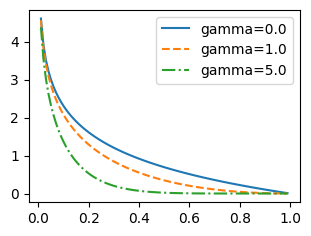

In [ ]:
def focal_loss(gamma, x):
    return -((1 - x) ** gamma) * torch.log(x)


x = torch.arange(0.01, 1, 0.01)
for l, gamma in zip(lines, [0, 1, 5]):
    y = plt.plot(x, focal_loss(gamma, x), l, label="gamma=%.1f" % gamma)
plt.legend()

# Exercise 3

In the loss function, assign different weight hyperparameters to the class loss and the offset loss.
